In [71]:
print("=" * 60)
print("NOTEBOOK 1 FINAL VERIFICATION")
print("=" * 60)

print("\nShape:", analysis_data.shape)

print("\nDuplicate Rows:", analysis_data.duplicated().sum())

print("\nMissing Values:")
print(analysis_data.isnull().sum())

print("\nData Types:")
print(analysis_data.dtypes)

print("\nDate Range:")
print(analysis_data["InvoiceDate"].min(), "to", analysis_data["InvoiceDate"].max())

print("\nUnique Customers:",
      analysis_data["CustomerID"].nunique())

print("\nUnique Products:",
      analysis_data["StockCode"].nunique())

print("\nUnique Countries:",
      analysis_data["Country"].nunique())

NOTEBOOK 1 FINAL VERIFICATION

Shape: (1007913, 15)

Duplicate Rows: 0

Missing Values:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     228488
Country             0
TotalAmount         0
Year                0
Month               0
MonthName           0
Day                 0
Weekday             0
Hour                0
dtype: int64

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
TotalAmount           float64
Year                    int32
Month                   int32
MonthName              object
Day                     int32
Weekday                object
Hour                    int32
dtype: object

Date Range:
2009-12-01 07:45:00 to 2011-12-09 12:50:00

Unique Customers: 5878

Unique Prod

In [69]:
print(analysis_data.shape)
print(analysis_data.isnull().sum())

(1007913, 15)
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     228488
Country             0
TotalAmount         0
Year                0
Month               0
MonthName           0
Day                 0
Weekday             0
Hour                0
dtype: int64


In [68]:
analysis_data.to_csv(
    "../data/processed/analysis_data.csv",
    index=False
)

## Data Cleaning Summary

The preprocessing pipeline was performed to create a clean and reliable transaction dataset for retail analytics.

The following steps were completed:

- Removed duplicate records within each worksheet.
- Merged the cleaned 2009–2010 and 2010–2011 datasets.
- Removed cross-sheet duplicate transactions caused by the overlapping period (2010-12-01 to 2010-12-09).
- Removed cancelled transactions.
- Removed inventory adjustment transactions.
- Removed negative UnitPrice records (bad-debt accounting adjustments).
- Removed zero UnitPrice non-revenue transactions after investigation.
- Retained missing CustomerID records for transaction-level analysis.
- Automatically excluded records without CustomerID during customer-level analyses such as RFM segmentation.
- Created TotalAmount, Year, Month, MonthName, Day, Weekday, and Hour features.

### Final Dataset Summary

- Total Transactions: **1,007,913**
- Total Features: **15**
- Duplicate Records: **0**
- Negative UnitPrice Records: **0**
- Zero UnitPrice Records: **0**
- Missing CustomerID: **228,488** (retained intentionally)

In [66]:
analysis_data = analysis_data.drop_duplicates()

print(analysis_data.shape)
print(analysis_data.duplicated().sum())

(1007913, 15)
0


In [ ]:
analysis_data[analysis_data.duplicated()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,MonthName,Day,Weekday,Hour


In [65]:
print(analysis_data.shape)

print("Duplicates:", analysis_data.duplicated().sum())

duplicate_rows = analysis_data[analysis_data.duplicated(keep=False)]

duplicate_rows.head(20)

(1007913, 15)
Duplicates: 0


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,MonthName,Day,Weekday,Hour


In [64]:
print("Missing Values")
print(analysis_data.isnull().sum())

print("\nNegative UnitPrice")
print((analysis_data["UnitPrice"] < 0).sum())

print("\nZero UnitPrice")
print((analysis_data["UnitPrice"] == 0).sum())

print("\nDuplicate Rows")
print(analysis_data.duplicated().sum())

Missing Values
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     228488
Country             0
TotalAmount         0
Year                0
Month               0
MonthName           0
Day                 0
Weekday             0
Hour                0
dtype: int64

Negative UnitPrice
0

Zero UnitPrice
0

Duplicate Rows
0


## Data Cleaning Summary

The following preprocessing steps were performed:

- Removed duplicate records.
- Removed cancelled transactions.
- Removed inventory adjustment transactions.
- Removed negative UnitPrice records (accounting adjustments).
- Removed zero UnitPrice non-revenue transactions after investigation.
- Retained missing CustomerID records for transaction-level analysis.
- Automatically excluded records without CustomerID during RFM customer segmentation.
- Created new features including TotalAmount, Year, Month, Day, Weekday, and Hour.

In [63]:
print(analysis_data.shape)

(1007913, 15)


In [70]:
print("=" * 60)
print("Saving Correct analysis_data.csv")
print("=" * 60)

analysis_data.to_csv(
    "../data/processed/analysis_data.csv",
    index=False
)

print("Saved Successfully!")

# Verify immediately
import pandas as pd

check = pd.read_csv(
    "../data/processed/analysis_data.csv",
    low_memory=False
)

print("\nShape :", check.shape)
print("\nColumns:")
print(check.columns.tolist())

Saving Correct analysis_data.csv
Saved Successfully!

Shape : (1007913, 15)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalAmount', 'Year', 'Month', 'MonthName', 'Day', 'Weekday', 'Hour']


In [ ]:
analysis_data.to_csv("../data/processed/retail_cleaned.csv", index=False)

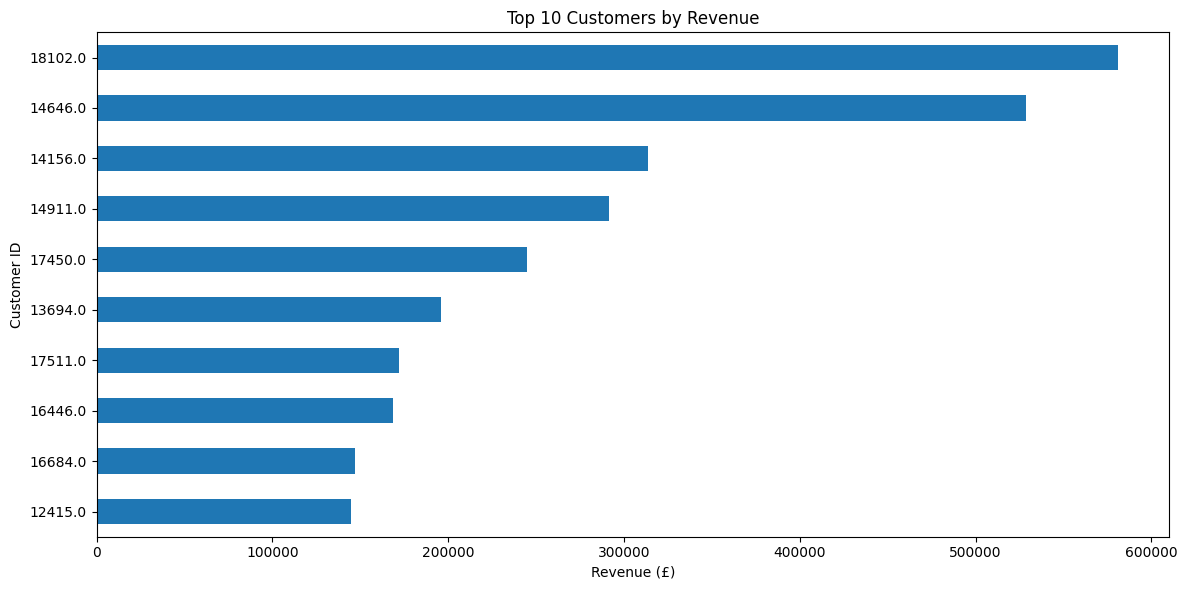

In [62]:
plt.figure(figsize=(12,6))

customer_sales.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

In [61]:
customer_sales = (
    analysis_data
    .groupby("CustomerID")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

print(customer_sales.head(10))

CustomerID
18102.0    580987.04
14646.0    528602.52
14156.0    313437.62
14911.0    291420.81
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: TotalAmount, dtype: float64


## Customer Purchase Analysis

Analyze customer purchasing behavior by identifying the highest-spending customers and understanding revenue contribution.

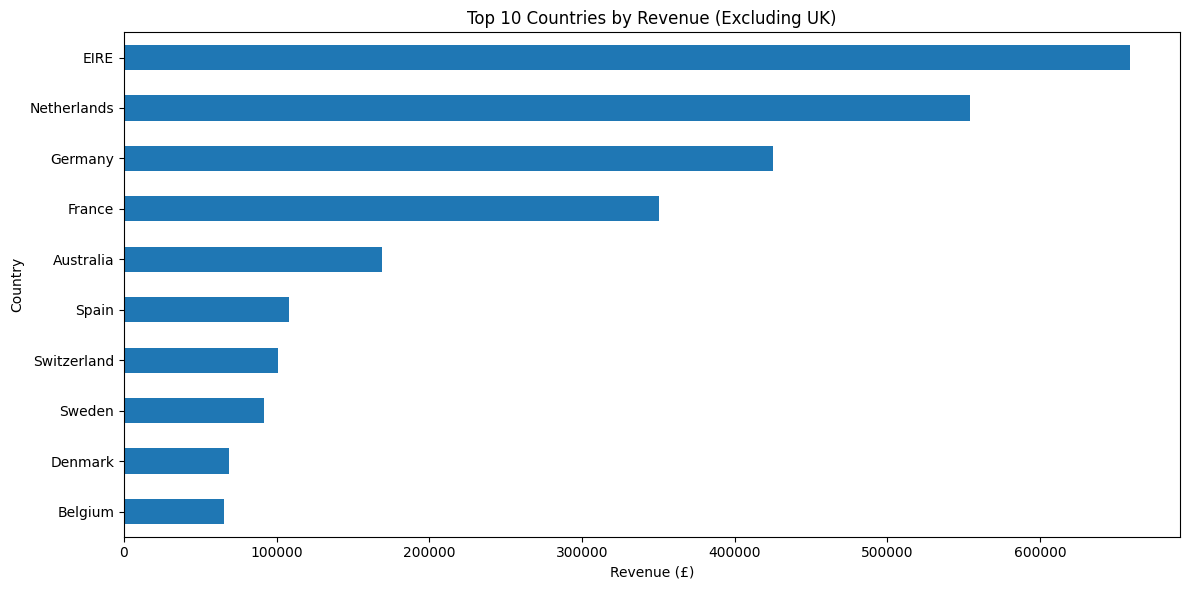

In [60]:
country_sales_ex_uk = (
    analysis_data[analysis_data["Country"] != "United Kingdom"]
    .groupby("Country")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

country_sales_ex_uk.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue (Excluding UK)")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

### Business Insights

1. The United Kingdom is the primary market, contributing the vast majority of total revenue.
2. EIRE, the Netherlands, Germany, and France are the strongest international markets.
3. Revenue distribution is highly concentrated in a few countries, indicating potential opportunities to expand sales in other regions.
4. Understanding country-level sales helps businesses optimize international marketing and logistics strategies.

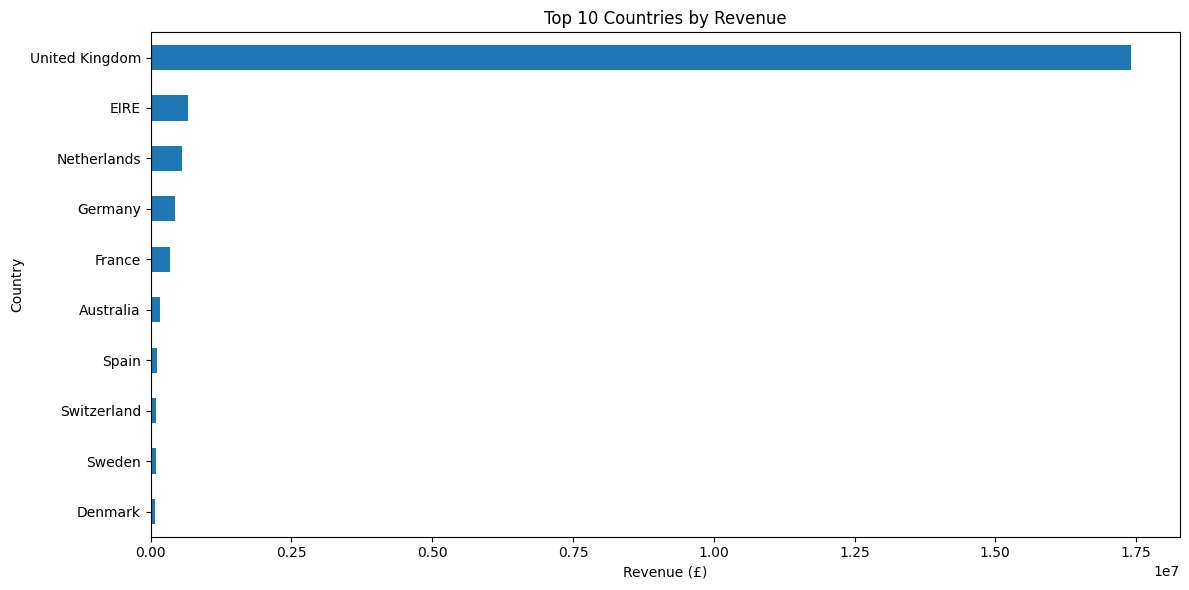

In [59]:
plt.figure(figsize=(12,6))

country_sales.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [58]:
country_sales = (
    analysis_data
    .groupby("Country")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

print(country_sales.head(10))

Country
United Kingdom    1.741020e+07
EIRE              6.587673e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.504561e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.006856e+05
Sweden            9.186982e+04
Denmark           6.858069e+04
Name: TotalAmount, dtype: float64


### Business Insights

1. "WORLD WAR 2 GLIDERS ASSTD DESIGNS" is the most frequently purchased product.
2. "WHITE HANGING HEART T-LIGHT HOLDER" performs strongly in both sales volume and revenue, indicating sustained customer demand.
3. High sales volume does not always translate to the highest revenue because product prices vary.
4. Administrative entries such as "Manual", "POSTAGE", and "DOTCOM POSTAGE" should be excluded from product-specific revenue analysis, as they do not represent physical retail products.

## Country-wise Sales Analysis

Analyze revenue generated across different countries to identify major markets and geographical sales distribution.

In [57]:
# Product-only dataset for product analysis

excluded_items = [
    "Manual",
    "POSTAGE",
    "DOTCOM POSTAGE"
]

product_data = analysis_data[
    ~analysis_data["Description"].isin(excluded_items)
].copy()

### Business Insights

- The most frequently purchased products are not always the highest revenue-generating products.
- High sales volume indicates customer popularity.
- High revenue products contribute significantly to overall business profitability.
- Identifying these products helps optimize inventory management and marketing strategies.

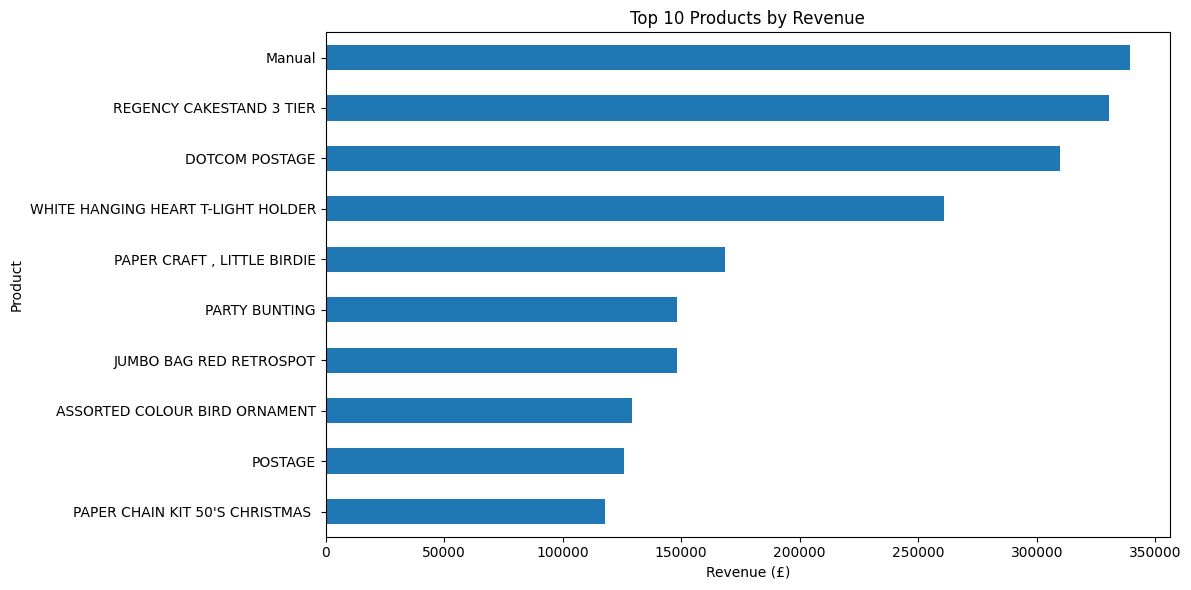

In [56]:
plt.figure(figsize=(12,6))

top_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [55]:
top_revenue = (
    analysis_data
    .groupby("Description")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_revenue)

Description
Manual                                339241.29
REGENCY CAKESTAND 3 TIER              330590.32
DOTCOM POSTAGE                        309854.11
WHITE HANGING HEART T-LIGHT HOLDER    260990.22
PAPER CRAFT , LITTLE BIRDIE           168469.60
PARTY BUNTING                         148318.28
JUMBO BAG RED RETROSPOT               148073.47
ASSORTED COLOUR BIRD ORNAMENT         129324.49
POSTAGE                               125682.42
PAPER CHAIN KIT 50'S CHRISTMAS        117760.29
Name: TotalAmount, dtype: float64


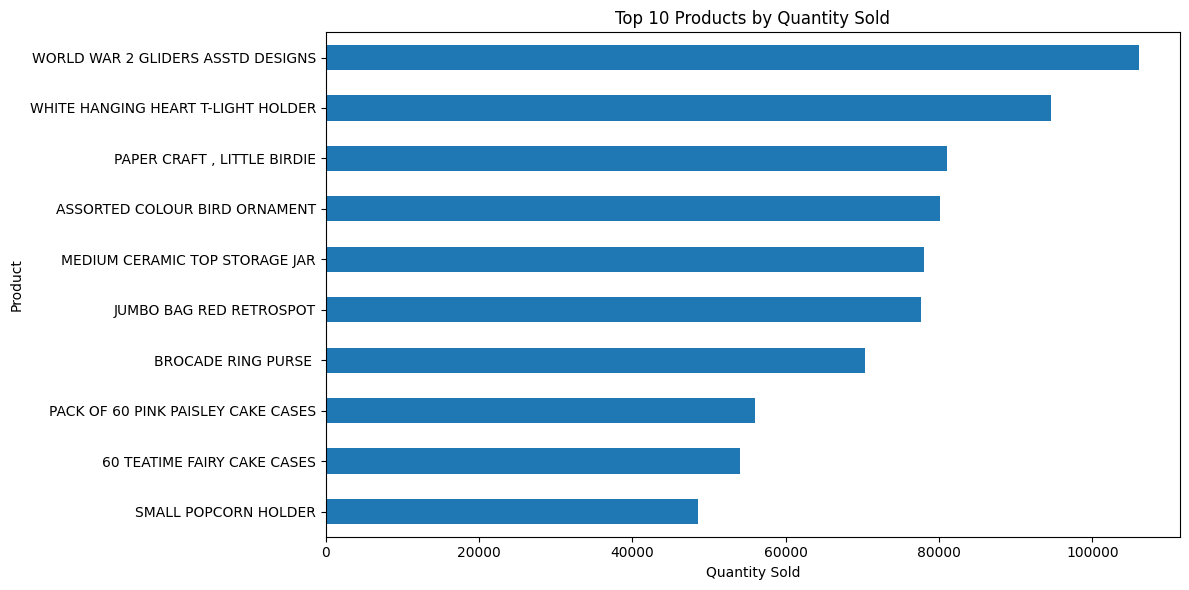

In [54]:
plt.figure(figsize=(12,6))

top_quantity.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [53]:
top_quantity = (
    analysis_data
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_quantity)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     106139
WHITE HANGING HEART T-LIGHT HOLDER     94658
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          80082
MEDIUM CERAMIC TOP STORAGE JAR         78033
JUMBO BAG RED RETROSPOT                77699
BROCADE RING PURSE                     70369
PACK OF 60 PINK PAISLEY CAKE CASES     56061
60 TEATIME FAIRY CAKE CASES            54028
SMALL POPCORN HOLDER                   48561
Name: Quantity, dtype: int64


## Product Performance Analysis

This section analyzes the best-selling products based on quantity sold and revenue generated to identify high-performing products and customer preferences.

### Business Insights

1. Revenue shows strong seasonal behavior with significant growth during September–November.
2. November is the highest revenue-generating month, indicating increased holiday shopping activity.
3. Sales are relatively lower during January and February.
4. The apparent decline in December 2011 is due to incomplete data, as the dataset ends on 9 December 2011.

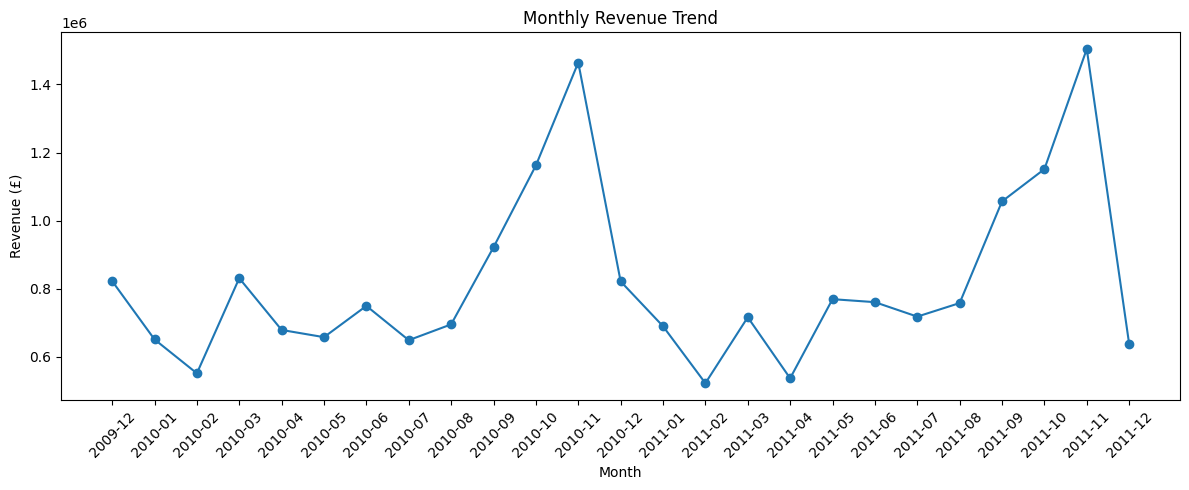

In [52]:
import matplotlib.pyplot as plt

monthly_sales = (
    analysis_data
    .groupby(["Year", "Month"])["TotalAmount"]
    .sum()
    .reset_index()
)

monthly_sales["Period"] = (
    monthly_sales["Year"].astype(str)
    + "-"
    + monthly_sales["Month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(12,5))
plt.plot(monthly_sales["Period"], monthly_sales["TotalAmount"], marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [51]:
print("=" * 50)
print("SALES OVERVIEW")
print("=" * 50)

print(f"Total Transactions : {analysis_data['InvoiceNo'].nunique():,}")
print(f"Total Customers    : {analysis_data['CustomerID'].nunique():,}")
print(f"Total Products     : {analysis_data['StockCode'].nunique():,}")
print(f"Countries          : {analysis_data['Country'].nunique():,}")

print(f"\nTotal Revenue      : £{analysis_data['TotalAmount'].sum():,.2f}")
print(f"Average Order Value: £{analysis_data.groupby('InvoiceNo')['TotalAmount'].sum().mean():,.2f}")

SALES OVERVIEW
Total Transactions : 40,077
Total Customers    : 5,878
Total Products     : 4,917
Countries          : 43

Total Revenue      : £20,476,260.45
Average Order Value: £510.92


# Exploratory Data Analysis (EDA)

This section explores the cleaned retail dataset to understand sales patterns, customer behavior, product performance, and business trends.

In [50]:
print("Zero-price transactions remaining:",
      (analysis_data["UnitPrice"] == 0).sum())

Zero-price transactions remaining: 0


In [49]:
# Remove zero-price transactions

analysis_data = analysis_data[analysis_data["UnitPrice"] > 0].copy()

print("Final Dataset Shape:")
print(analysis_data.shape)

Final Dataset Shape:
(1007913, 15)


## Remove Zero Unit Price Transactions

Transactions with a unit price of zero were investigated before removal. Most of these records had missing customer IDs and represented internal adjustments, administrative entries, free items, or non-revenue transactions rather than actual retail sales.

Since the objective of this project is to analyze customer purchasing behavior and sales performance, these records were excluded from the final analytical dataset.

In [48]:
# Inspect transactions with zero unit price

zero_price = analysis_data[analysis_data["UnitPrice"] == 0]

print("Shape:", zero_price.shape)
print("\nMissing CustomerID:", zero_price["CustomerID"].isna().sum())
print("\nInvoice starts with C:")
print(zero_price["InvoiceNo"].astype(str).str.startswith("C").value_counts())

print("\nTop Descriptions:")
print(zero_price["Description"].value_counts().head(20))

print("\nSample Records:")
zero_price.head(20)

Shape: (2621, 15)

Missing CustomerID: 2551

Invoice starts with C:
InvoiceNo
False    2621
Name: count, dtype: int64

Top Descriptions:
Description
check                              39
found                              28
OWL DOORSTOP                       14
adjustment                         14
POLYESTER FILLER PAD 45x45cm       12
POLYESTER FILLER PAD 40x40cm       10
Found                               9
FRENCH BLUE METAL DOOR SIGN 1       9
?                                   9
PICNIC BASKET WICKER LARGE          8
FRENCH BLUE METAL DOOR SIGN 8       8
RECIPE BOX PANTRY YELLOW DESIGN     8
amazon                              8
RED KITCHEN SCALES                  8
IVORY KITCHEN SCALES                8
BOX OF 24 COCKTAIL PARASOLS         8
WATERING CAN BLUE ELEPHANT          7
ENAMEL WASH BOWL CREAM              7
FRENCH BLUE METAL DOOR SIGN 4       7
FRENCH BLUE METAL DOOR SIGN No      7
Name: count, dtype: int64

Sample Records:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,MonthName,Day,Weekday,Hour
3009,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom,0.0,2009,12,December,1,Tuesday,17
3562,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom,0.0,2009,12,December,2,Wednesday,11
4474,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom,0.0,2009,12,December,2,Wednesday,13
5695,489861,DOT,DOTCOM POSTAGE,1,2009-12-02 14:50:00,0.0,NaN,United Kingdom,0.0,2009,12,December,2,Wednesday,14
6159,489882,35751C,NaN,12,2009-12-02 16:22:00,0.0,NaN,United Kingdom,0.0,2009,12,December,2,Wednesday,16
6336,489898,79323G,NaN,954,2009-12-03 09:40:00,0.0,NaN,United Kingdom,0.0,2009,12,December,3,Thursday,9
6360,489903,21166,NaN,48,2009-12-03 09:57:00,0.0,NaN,United Kingdom,0.0,2009,12,December,3,Thursday,9
6551,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom,0.0,2009,12,December,3,Thursday,11
6971,490015,21982,NaN,467,2009-12-03 12:29:00,0.0,NaN,United Kingdom,0.0,2009,12,December,3,Thursday,12
8976,490123,84508B,NaN,184,2009-12-03 18:08:00,0.0,NaN,United Kingdom,0.0,2009,12,December,3,Thursday,18


In [47]:
analysis_data[analysis_data["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,MonthName,Day,Weekday,Hour


In [46]:
# Remove accounting adjustment records with negative unit prices

analysis_data = analysis_data[analysis_data["UnitPrice"] >= 0].copy()

print("Dataset Shape After Removing Negative Unit Price Records:")
print(analysis_data.shape)

Dataset Shape After Removing Negative Unit Price Records:
(1010534, 15)


## Handle Negative Unit Price Records

The dataset contains a small number of accounting adjustment transactions ("Adjust bad debt") with negative unit prices and no customer information. These records do not represent actual retail sales and are removed from the analysis dataset to ensure accurate business insights.

In [45]:
# Check transactions with zero unit price

zero_price = analysis_data[analysis_data["UnitPrice"] == 0]

print("Transactions with Zero Unit Price")
print("-" * 45)
print(f"Count : {len(zero_price)}")

Transactions with Zero Unit Price
---------------------------------------------
Count : 2621


In [44]:
# Check transactions with negative unit prices

negative_price = analysis_data[analysis_data["UnitPrice"] < 0]

print("Transactions with Negative Unit Price")
print("-" * 45)
print(f"Count : {len(negative_price)}")

negative_price.head(10)

Transactions with Negative Unit Price
---------------------------------------------
Count : 5


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,MonthName,Day,Weekday,Hour
172750,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom,-53594.36,2010,4,April,29,Thursday,13
265615,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom,-44031.79,2010,7,July,19,Monday,11
388652,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom,-38925.87,2010,10,October,20,Wednesday,12
775791,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,-11062.06,2011,8,August,12,Friday,14
775792,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,-11062.06,2011,8,August,12,Friday,14


## Validate Negative Unit Prices

Identify transactions with negative unit prices to determine whether they represent valid sales or data quality issues.

In [43]:
print("analysis_data shape:", analysis_data.shape)
print("\nColumns:")
print(analysis_data.columns.tolist())

analysis_data shape: (1010539, 15)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalAmount', 'Year', 'Month', 'MonthName', 'Day', 'Weekday', 'Hour']


In [42]:
analysis_data.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,MonthName,Day,Weekday,Hour
count,1010539.0,1010539,1008897,1.010539e+06,1010539,1.010539e+06,779495.000000,1010539,1.010539e+06,1.010539e+06,1.010539e+06,1010539,1.010539e+06,1010539,1.010539e+06
unique,41943.0,4985,5469,NaN,NaN,NaN,NaN,43,NaN,NaN,NaN,12,NaN,7,NaN
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom,NaN,NaN,NaN,November,NaN,Thursday,NaN
freq,1114.0,5517,5606,NaN,NaN,NaN,NaN,928637,NaN,NaN,NaN,157300,NaN,190921,NaN
mean,NaN,NaN,NaN,1.133644e+01,2011-01-04 07:06:54.334924544,3.906643e+00,15320.262918,NaN,2.010569e+01,2.010437e+03,7.402808e+00,NaN,1.535302e+01,NaN,1.302072e+01
min,NaN,NaN,NaN,1.000000e+00,2009-12-01 07:45:00,-5.359436e+04,12346.000000,NaN,-5.359436e+04,2.009000e+03,1.000000e+00,NaN,1.000000e+00,NaN,6.000000e+00
25%,NaN,NaN,NaN,1.000000e+00,2010-07-06 09:51:00,1.250000e+00,13971.000000,NaN,4.130000e+00,2.010000e+03,4.000000e+00,NaN,8.000000e+00,NaN,1.100000e+01
50%,NaN,NaN,NaN,4.000000e+00,2010-12-09 14:27:00,2.100000e+00,15246.000000,NaN,1.008000e+01,2.010000e+03,8.000000e+00,NaN,1.500000e+01,NaN,1.300000e+01
75%,NaN,NaN,NaN,1.200000e+01,2011-07-28 10:33:00,4.130000e+00,16794.000000,NaN,1.770000e+01,2.011000e+03,1.100000e+01,NaN,2.300000e+01,NaN,1.500000e+01
max,NaN,NaN,NaN,8.099500e+04,2011-12-09 12:50:00,2.511109e+04,18287.000000,NaN,1.684696e+05,2.011000e+03,1.200000e+01,NaN,3.100000e+01,NaN,2.000000e+01


In [41]:
# Dataset Overview

print("Dataset Shape :", analysis_data.shape)
print("Number of Customers :", analysis_data["CustomerID"].nunique())
print("Number of Products :", analysis_data["StockCode"].nunique())
print("Number of Countries :", analysis_data["Country"].nunique())
print("Date Range :")
print(
    analysis_data["InvoiceDate"].min(),
    "to",
    analysis_data["InvoiceDate"].max()
)

Dataset Shape : (1010539, 15)
Number of Customers : 5881
Number of Products : 4985
Number of Countries : 43
Date Range :
2009-12-01 07:45:00 to 2011-12-09 12:50:00


# Exploratory Data Analysis (EDA)

Analyze customer purchasing behavior, product performance, sales trends, and geographic distribution to generate business insights.

In [40]:
analysis_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,MonthName,Day,Weekday,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December,1,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,1,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,1,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,December,1,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,December,1,Tuesday,7


In [39]:
# Create date-based features

analysis_data["Year"] = analysis_data["InvoiceDate"].dt.year
analysis_data["Month"] = analysis_data["InvoiceDate"].dt.month
analysis_data["MonthName"] = analysis_data["InvoiceDate"].dt.month_name()
analysis_data["Day"] = analysis_data["InvoiceDate"].dt.day
analysis_data["Weekday"] = analysis_data["InvoiceDate"].dt.day_name()
analysis_data["Hour"] = analysis_data["InvoiceDate"].dt.hour

print("New features created successfully!")

New features created successfully!


In [38]:
# Create Total Amount (Revenue)

analysis_data["TotalAmount"] = (
    analysis_data["Quantity"] *
    analysis_data["UnitPrice"]
)

## Feature Engineering

Create additional features to support exploratory data analysis and customer analytics.

In [37]:
# ==========================================================
# Final Duplicate Removal After Merging Both Worksheets
# ==========================================================

print(f"Shape before final duplicate removal : {analysis_data.shape}")
print(f"Duplicate rows before removal        : {analysis_data.duplicated().sum()}")

analysis_data = analysis_data.drop_duplicates().reset_index(drop=True)

print(f"\nShape after final duplicate removal  : {analysis_data.shape}")
print(f"Duplicate rows after removal         : {analysis_data.duplicated().sum()}")

Shape before final duplicate removal : (1032348, 8)
Duplicate rows before removal        : 21809

Shape after final duplicate removal  : (1010539, 8)
Duplicate rows after removal         : 0


## Final Duplicate Removal After Merging

The Online Retail II workbook contains two worksheets (2009–2010 and 2010–2011).

After removing duplicate records within each worksheet, the cleaned datasets were concatenated into a single transaction dataset. During validation, it was found that the workbook contains an overlapping period (2010-12-01 to 2010-12-09), resulting in identical transactions appearing in both worksheets.

A final duplicate check was therefore performed after merging to remove these cross-sheet duplicate records.

This step removes only exact duplicate transactions created by the worksheet overlap and does not remove any legitimate sales records.

**Reason:**
- Remove duplicate transactions caused by overlapping workbook sheets.
- Prevent double-counting of sales, customers, and revenue.
- Ensure accurate EDA, RFM segmentation, and downstream machine learning models.

In [36]:
analysis_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1032348 entries, 0 to 1032347
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   InvoiceNo    1032348 non-null  object        
 1   StockCode    1032348 non-null  object        
 2   Description  1030655 non-null  object        
 3   Quantity     1032348 non-null  int64         
 4   InvoiceDate  1032348 non-null  datetime64[ns]
 5   UnitPrice    1032348 non-null  float64       
 6   CustomerID   793680 non-null   float64       
 7   Country      1032348 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 63.0+ MB


In [35]:
print("Merged Dataset Information")
print("-" * 40)

print(f"Shape : {analysis_data.shape}")

analysis_data.head()

Merged Dataset Information
----------------------------------------
Shape : (1032348, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [34]:
# Combine both cleaned datasets

analysis_data = pd.concat(
    [analysis_2009, analysis_2010],
    ignore_index=True
)

print("Datasets merged successfully!")

Datasets merged successfully!


## Merge Cleaned Datasets

Combine the cleaned datasets from 2009–2010 and 2010–2011 into a single analysis dataset for subsequent exploratory data analysis and customer analytics.

In [33]:
print("Analysis Dataset Shape")
print("-" * 40)

print(f"2009-2010 : {analysis_2009.shape}")
print(f"2010-2011 : {analysis_2010.shape}")

Analysis Dataset Shape
----------------------------------------
2009-2010 : (506293, 8)
2010-2011 : (526055, 8)


In [32]:
# Keep only valid sales transactions

analysis_2009 = analysis_2009[
    (analysis_2009["Quantity"] > 0) &
    (~analysis_2009["InvoiceNo"].astype(str).str.startswith("C"))
]

analysis_2010 = analysis_2010[
    (analysis_2010["Quantity"] > 0) &
    (~analysis_2010["InvoiceNo"].astype(str).str.startswith("C"))
]

print("Valid Sales Dataset Created Successfully!")

Valid Sales Dataset Created Successfully!


In [31]:
# Create copies for analysis

analysis_2009 = retail_2009.copy()
analysis_2010 = retail_2010.copy()

## Create Analysis Dataset

Create cleaned copies of the datasets for customer and sales analytics by excluding cancelled transactions and internal inventory adjustment records.

In [30]:
print("2009-2010")
display(non_cancelled_negative_2009.head(10))

print("\n2010-2011")
display(non_cancelled_negative_2010.head(10))

2009-2010


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom
4538,489820,21133,invcd as 84879?,-720,2009-12-02 13:23:00,0.0,NaN,United Kingdom
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom



2010-2011


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


## Inspect Negative Quantities Without Cancelled Invoices

Display a sample of transactions where the quantity is negative but the invoice number does not start with 'C'. This helps identify data inconsistencies or special transaction types.

In [29]:
# Check for negative quantities that are NOT cancelled invoices

non_cancelled_negative_2009 = retail_2009[
    (retail_2009["Quantity"] < 0) &
    (~retail_2009["InvoiceNo"].astype(str).str.startswith("C"))
]

non_cancelled_negative_2010 = retail_2010[
    (retail_2010["Quantity"] < 0) &
    (~retail_2010["InvoiceNo"].astype(str).str.startswith("C"))
]

print("Negative Quantity WITHOUT Cancelled Invoice")
print("-" * 45)

print(f"2009-2010 : {len(non_cancelled_negative_2009)}")
print(f"2010-2011 : {len(non_cancelled_negative_2010)}")

Negative Quantity WITHOUT Cancelled Invoice
---------------------------------------------
2009-2010 : 2121
2010-2011 : 1336


In [28]:
# Count transactions with negative quantities

negative_qty_2009 = (retail_2009["Quantity"] < 0).sum()
negative_qty_2010 = (retail_2010["Quantity"] < 0).sum()

print("Transactions with Negative Quantity")
print("-" * 45)

print(f"2009-2010 : {negative_qty_2009:,}")
print(f"2010-2011 : {negative_qty_2010:,}")

Transactions with Negative Quantity
---------------------------------------------
2009-2010 : 12,302
2010-2011 : 10,587


## Relationship Between Cancelled Invoices and Negative Quantities

Verify whether all transactions with negative quantities are associated with cancelled invoice numbers.

In [27]:
print("Sample Cancelled Transactions (2009-2010)")
display(
    retail_2009[
        retail_2009["InvoiceNo"].astype(str).str.startswith("C")
    ].head()
)

print("\nSample Cancelled Transactions (2010-2011)")
display(
    retail_2010[
        retail_2010["InvoiceNo"].astype(str).str.startswith("C")
    ].head()
)

Sample Cancelled Transactions (2009-2010)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia



Sample Cancelled Transactions (2010-2011)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [26]:
# Calculate cancellation percentage

cancelled_percentage_2009 = (cancelled_2009 / len(retail_2009)) * 100
cancelled_percentage_2010 = (cancelled_2010 / len(retail_2010)) * 100

print(f"2009-2010 Cancellation Percentage : {cancelled_percentage_2009:.2f}%")
print(f"2010-2011 Cancellation Percentage : {cancelled_percentage_2010:.2f}%")

2009-2010 Cancellation Percentage : 1.96%
2010-2011 Cancellation Percentage : 1.72%


In [25]:
# Count cancelled transactions

cancelled_2009 = retail_2009["InvoiceNo"].astype(str).str.startswith("C").sum()
cancelled_2010 = retail_2010["InvoiceNo"].astype(str).str.startswith("C").sum()

print("Cancelled Transactions")
print("-" * 40)

print(f"2009-2010 : {cancelled_2009:,}")
print(f"2010-2011 : {cancelled_2010:,}")

Cancelled Transactions
----------------------------------------
2009-2010 : 10,182
2010-2011 : 9,251


## Analyze Cancelled Transactions

Identify invoices beginning with 'C' to understand the volume of cancelled or returned transactions before preprocessing.

In [24]:
# Verify duplicate removal

print("Remaining Duplicates")
print("-" * 40)

print("2009-2010:", retail_2009.duplicated().sum())
print("2010-2011:", retail_2010.duplicated().sum())

print("\nUpdated Dataset Shapes")
print("-" * 40)

print("2009-2010:", retail_2009.shape)
print("2010-2011:", retail_2010.shape)

Remaining Duplicates
----------------------------------------
2009-2010: 0
2010-2011: 0

Updated Dataset Shapes
----------------------------------------
2009-2010: (518596, 8)
2010-2011: (536642, 8)


In [23]:
# Remove exact duplicate records

retail_2009 = retail_2009.drop_duplicates()
retail_2010 = retail_2010.drop_duplicates()

print("Duplicate records removed successfully.")

Duplicate records removed successfully.


## Remove Exact Duplicate Records

Remove exact duplicate records from both datasets while keeping the first occurrence. This prevents duplicate transactions from affecting downstream analysis.

In [22]:
# Display the first few duplicate rows

print("Duplicate Records - 2009-2010")
display(retail_2009[retail_2009.duplicated()].head())

print("\nDuplicate Records - 2010-2011")
display(retail_2010[retail_2010.duplicated()].head())

Duplicate Records - 2009-2010


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom



Duplicate Records - 2010-2011


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


## Inspect Duplicate Records

Display a sample of duplicate records to determine whether they represent genuine duplicate transactions or valid repeated purchases.

In [21]:
# Display duplicate percentage

duplicate_percentage_2009 = (duplicate_2009 / len(retail_2009)) * 100
duplicate_percentage_2010 = (duplicate_2010 / len(retail_2010)) * 100

print(f"2009-2010 Duplicate Percentage : {duplicate_percentage_2009:.2f}%")
print(f"2010-2011 Duplicate Percentage : {duplicate_percentage_2010:.2f}%")

2009-2010 Duplicate Percentage : 1.31%
2010-2011 Duplicate Percentage : 0.97%


In [20]:
# Check duplicate rows in each dataset

print("Duplicate Records")
print("-" * 50)

duplicate_2009 = retail_2009.duplicated().sum()
duplicate_2010 = retail_2010.duplicated().sum()

print(f"2009-2010 Dataset : {duplicate_2009:,}")
print(f"2010-2011 Dataset : {duplicate_2010:,}")

Duplicate Records
--------------------------------------------------
2009-2010 Dataset : 6,865
2010-2011 Dataset : 5,268


## Duplicate Record Analysis

Check for duplicate records in both datasets before deciding whether duplicate transactions should be removed.

In [19]:
missing_value_summary(retail_2009, "2009-2010 Dataset")
missing_value_summary(retail_2010, "2010-2011 Dataset")


2009-2010 Dataset
--------------------------------------------------


,Missing Values,Percentage (%)
CustomerID,107927,20.54
Description,2928,0.56



2010-2011 Dataset
--------------------------------------------------


,Missing Values,Percentage (%)
CustomerID,135080,24.93
Description,1454,0.27


In [18]:
# Function to display missing value summary

def missing_value_summary(df, dataset_name):
    missing = df.isnull().sum()
    percentage = (missing / len(df)) * 100

    summary = pd.DataFrame({
        "Missing Values": missing,
        "Percentage (%)": percentage.round(2)
    })

    summary = summary[summary["Missing Values"] > 0]

    print(f"\n{dataset_name}")
    print("-" * 50)

    if summary.empty:
        print("No missing values found.")
    else:
        display(summary.sort_values("Missing Values", ascending=False))

## Missing Value Analysis

Analyze missing values in both datasets before deciding how to handle them during preprocessing.

In [16]:
# Display general information about each dataset

print("2009-2010 Dataset Information")
print("-" * 40)
retail_2009.info()

print("\n2010-2011 Dataset Information")
print("-" * 40)
retail_2010.info()

2009-2010 Dataset Information
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   UnitPrice    525461 non-null  float64       
 6   CustomerID   417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB

2010-2011 Dataset Information
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  

In [15]:
# Display data types of both datasets

print("2009-2010 Data Types")
print("-" * 40)
print(retail_2009.dtypes)

print("\n2010-2011 Data Types")
print("-" * 40)
print(retail_2010.dtypes)

2009-2010 Data Types
----------------------------------------
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

2010-2011 Data Types
----------------------------------------
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


## Inspect Data Types

Verify the data type of each column to identify any necessary conversions before preprocessing.

In [14]:
print("Columns in 2009 Dataset")
print(retail_2009.columns.tolist())

print("\nColumns in 2010 Dataset")
print(retail_2010.columns.tolist())

Columns in 2009 Dataset
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Columns in 2010 Dataset
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [13]:
standard_columns = {
    "Invoice": "InvoiceNo",
    "Price": "UnitPrice",
    "Customer ID": "CustomerID"
}
retail_2009.rename(columns=standard_columns, inplace=True)
retail_2010.rename(columns=standard_columns, inplace=True)

print("Column names standardized successfully!")

Column names standardized successfully!


## Standardize Column Names

To maintain consistency throughout the project, column names are standardized across both worksheets.

In [12]:
print("2009-2010 Shape:", retail_2009.shape)
print("2010-2011 Shape:", retail_2010.shape)

2009-2010 Shape: (525461, 8)
2010-2011 Shape: (541910, 8)


In [11]:
# Load each worksheet into a separate DataFrame

retail_2009 = retail_data["Year 2009-2010"].copy()
retail_2010 = retail_data["Year 2010-2011"].copy()

print("Both worksheets loaded into separate DataFrames.")

Both worksheets loaded into separate DataFrames.


## Load Individual Worksheets

Create separate DataFrames for each worksheet to make preprocessing and comparison easier.

In [10]:
# Display column names for each sheet

for sheet_name, df in retail_data.items():

    print(f"\n{sheet_name}")
    print("\n")

    for column in df.columns:
        print(column)


Year 2009-2010


Invoice
StockCode
Description
Quantity
InvoiceDate
Price
Customer ID
Country

Year 2010-2011


Invoice
StockCode
Description
Quantity
InvoiceDate
Price
Customer ID
Country


In [8]:
# Display the dimensions of each worksheet

print("Workbook Summary")
print("\n")
for sheet_name, df in retail_data.items():
    rows, cols = df.shape

    print(f"Sheet Name : {sheet_name}")
    print(f"Rows  : {rows:,}")
    print(f"Columns : {cols}")
    print("\n")

Workbook Summary


Sheet Name : Year 2009-2010
Rows  : 525,461
Columns : 8


Sheet Name : Year 2010-2011
Rows  : 541,910
Columns : 8




In [7]:
# Display all sheet names

print("Available Sheets:")
print("-" * 40)

for sheet_name in retail_data.keys():
    print(sheet_name)

Available Sheets:
----------------------------------------
Year 2009-2010
Year 2010-2011


## Inspect Workbook Structure

This step verifies the workbook structure by identifying all available worksheets and their dimensions before performing any preprocessing or analysis.

In [5]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\notebooks


In [4]:
# Relative path to the dataset
dataset_path = "../../../online+retail+ii/online_retail_II.xlsx"

# Load all sheets
retail_data = pd.read_excel(dataset_path, sheet_name=None)

print("Workbook loaded successfully!")

Workbook loaded successfully!


## Load the Dataset

In this step, we load both sheets from the Online Retail II Excel workbook and verify that they are accessible before performing any analysis.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns when viewing DataFrames
pd.set_option("display.max_columns", None)

# Display wider DataFrames neatly
pd.set_option("display.width", 1000)

# RetailPulse AI Customer Analytics

## Notebook 01: Data Preparation

### Objective
This notebook loads the Online Retail II dataset, validates its structure, and prepares it for exploratory data analysis (EDA).

Author: Nishanth C P

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!
